## Preprocess BactHeCom DB

In [99]:
import os
import pandas as pd
import numpy as np
import sqlite3
import requests
from datetime import datetime
from dateutil.relativedelta import relativedelta

from utils import *

import warnings
warnings.filterwarnings('ignore')

In [100]:
# paths
data_dir = "../data"
results_dir = "../results"
os.makedirs(results_dir, exist_ok=True)
bacthecom_db=f"{data_dir}/db_bacthecom.db"

In [101]:
## Load database 
conn = sqlite3.connect(bacthecom_db)

tbls = pd.read_sql_query("SELECT * FROM sqlite_master WHERE type='table';", con=conn)
tbls = tbls[tbls['name'] != 'sqlite_sequence']
print(f"Tables in the database: {tbls['name'].values}")

Tables in the database: ['paciente' 'factores_riesgo_infeccion_bmr' 'antibiograma'
 'semantic_mapping' 'episodio_infeccion' 'comorbilidad' 'signos_sintomas'
 'episodio_ingreso']


In [102]:
for tbl in tbls['name']:
    if tbl == "sqlite_sequence":
        continue    
    df = pd.read_sql_query(f"SELECT * FROM {tbl} LIMIT 5;", con=conn)
    print(f"{tbl}: {df.columns.values}")
    print("\n") 

paciente: ['record_id' 'sexo' 'fecha_nacimiento']


factores_riesgo_infeccion_bmr: ['record_id' 'fecha_ingreso' 'hospit_ano_previo' 'hospit_mes_previo'
 'hospit_ano_previo_uci' 'hemodialisis_permanente' 'dialisis_peritoneal'
 'cateter_venoso' 'sonda_urinaria' 'sonda_nasogastrica'
 'derivacion_ventriculoper' 'valvula_prot_cardiaca'
 'portador_otros_disposit']


antibiograma: ['episode_id' 'antimicrobiano' 'cmi' 'interpretacion']


semantic_mapping: ['table_name' 'variable_name' 'description' 'uri']


episodio_infeccion: ['episode_id' 'record_id' 'fecha_ingreso' 'fecha_cultivo' 'area_hosp'
 'id_cultivo' 'especimen' 'microorganismo' 'fenotipo_resistencia']


comorbilidad: ['record_id' 'fecha_ingreso' 'infarto' 'insuficiencia_cardiaca' 'evp'
 'e_cerebrovascular' 'demencia' 'e_pulmonar_cronica' 'ulcera_peptica'
 'colagenopatia' 'hemiplejia' 'erc' 'neoplasia_tratamiento_activo'
 'neoplasia_solida_metastasica' 'neoplasia_solida_no_metastasica'
 'tipo_cancer' 'linfoma' 'leucemia' 'sida' 'punta

## Preprocess and recode variables for ML modeling

### tbl_pacientes

In [103]:
tbl_pacientes = pd.read_sql_query("SELECT * FROM paciente;", con=conn)
tbl_pacientes.head()

,record_id,sexo,fecha_nacimiento
0,1,Hombre,1943-03-28
1,2,Mujer,1959-12-16
2,3,Hombre,1976-11-14
3,4,Hombre,1992-09-27
4,5,Mujer,1994-07-13


In [104]:
# Recode 'Hombre'/'Mujer' to 0/1
tbl_pacientes['sexo'] = tbl_pacientes['sexo'].map({'Hombre': 0, 'Mujer': 1})

### tbl_factores_riesgo_infeccion_bmr

In [105]:
tbl_factores_bmr = pd.read_sql_query("SELECT * FROM factores_riesgo_infeccion_bmr;", con=conn)
tbl_factores_bmr.head() 

,record_id,fecha_ingreso,hospit_ano_previo,hospit_mes_previo,hospit_ano_previo_uci,hemodialisis_permanente,dialisis_peritoneal,cateter_venoso,sonda_urinaria,sonda_nasogastrica,derivacion_ventriculoper,valvula_prot_cardiaca,portador_otros_disposit
0,1,2021-08-24,0,0,0,0,0,0,0,1,0,0,0
1,2,2023-06-18,0,0,0,0,0,0,0,1,0,0,0
2,3,2022-02-11,1,0,1,0,0,0,0,1,0,0,0
3,4,2021-05-15,0,0,0,0,0,0,0,1,0,0,0
4,5,2021-07-04,0,0,0,0,0,0,0,0,0,0,0


### tbl_episodios

In [106]:
tbl_episodios = pd.read_sql_query("SELECT * FROM episodio_ingreso;", con=conn)
tbl_episodios.fillna(0, inplace=True)
tbl_episodios.head()

,record_id,fecha_ingreso,fecha_alta,organo_aparato,foco_controlable,IRAs_nosocomial,mortalidad,uci_por_el_episodio,duracion_UCI,mujer_gestante,codigo_postal,paciente_residencia
0,1,2021-08-24,2021-09-09,0,0.0,Si,1,1,14,0,4007,0.0
1,2,2023-06-18,2023-07-13,0,0.0,Si,0,1,3,0,4740,0.0
2,3,2022-02-11,2022-04-06,Infeccion de cateter vascular,1.0,Si,0,1,24,0,4700,0.0
3,4,2021-05-15,2021-07-28,0,0.0,Si,0,1,42,0,18800,0.0
4,5,2021-07-04,2022-01-04,Infeccion tracto respiratorio inferior,0.0,Si,0,1,78,0,23009,0.0


In [107]:
# Recode IRAs_nosocomial to '0/1'
tbl_episodios['IRAs_nosocomial'] = tbl_episodios['IRAs_nosocomial'].map({'No': 0, 'Si': 1})

In [108]:
tbl_episodios['organo_aparato'].value_counts()

organo_aparato
0                                         2139
Infección de la vía urinaria superior      444
Fiebre sin foco                            275
Infeccion de cateter vascular              166
Infeccion vias biliares                    137
Infeccion intraabdominal                   127
Infeccion tracto respiratorio inferior      96
Infeccion de piel y partes blandas          78
Infeccion cardiovascular                    16
Infeccion osteoarticular                    11
Otros/Infeccion de etiologia incierta        9
Infeccion del SNC                            2
Infeccion genital                            1
Name: count, dtype: int64

In [109]:
# rename organo aparato values
infecname_to_infeccode = {
    'via_urinaria_superior': 'Infección de la vía urinaria superior',
    'fiebre_sin_foco': 'Fiebre sin foco',
    'cateter_vascular': 'Infeccion de cateter vascular',
    'vias_biliares': 'Infeccion vias biliares',
    'intraabdominal': 'Infeccion intraabdominal',
    'tracto_respiratorio_inferior': 'Infeccion tracto respiratorio inferior',
    'piel': 'Infeccion de piel y partes blandas',
    'cardiovascular': 'Infeccion cardiovascular',
    'osteoarticular': 'Infeccion osteoarticular',
    'etiologia_incierta': 'Otros/Infeccion de etiologia incierta',
    'snc': 'Infeccion del SNC',
    'genital': 'Infeccion genital'
}


In [110]:
# rename organo_aparato
tbl_episodios['organo_aparato'] = tbl_episodios['organo_aparato'].map({v: k for k, v in infecname_to_infeccode.items()})

# One-hot encode the 'organo_aparato' column
tbl_episodios_recoded = pd.get_dummies(tbl_episodios, columns=['organo_aparato'], prefix='infec',dtype=int)
tbl_episodios_recoded.head()


,record_id,fecha_ingreso,fecha_alta,foco_controlable,IRAs_nosocomial,mortalidad,uci_por_el_episodio,duracion_UCI,mujer_gestante,codigo_postal,...,infec_etiologia_incierta,infec_fiebre_sin_foco,infec_genital,infec_intraabdominal,infec_osteoarticular,infec_piel,infec_snc,infec_tracto_respiratorio_inferior,infec_via_urinaria_superior,infec_vias_biliares
0,1,2021-08-24,2021-09-09,0.0,1,1,1,14,0,4007,...,0,0,0,0,0,0,0,0,0,0
1,2,2023-06-18,2023-07-13,0.0,1,0,1,3,0,4740,...,0,0,0,0,0,0,0,0,0,0
2,3,2022-02-11,2022-04-06,1.0,1,0,1,24,0,4700,...,0,0,0,0,0,0,0,0,0,0
3,4,2021-05-15,2021-07-28,0.0,1,0,1,42,0,18800,...,0,0,0,0,0,0,0,0,0,0
4,5,2021-07-04,2022-01-04,0.0,1,0,1,78,0,23009,...,0,0,0,0,0,0,0,1,0,0


### tbl_comorbilidad
- Clusterizar cancer en clases y pivotar en columnas y codificar **0/1**

In [111]:
tbl_comorbilidades = pd.read_sql_query("SELECT * FROM comorbilidad;", con=conn)
tbl_comorbilidades.head()

,record_id,fecha_ingreso,infarto,insuficiencia_cardiaca,evp,e_cerebrovascular,demencia,e_pulmonar_cronica,ulcera_peptica,colagenopatia,...,diabetes_sin_lesion_organo_diana,diabetes_con_lesion_organo_diana,inmunosupresion,causa_inmunosupresion,fecha_TOS,TOS,fecha_TPH,TPH,clasificacion_quemadura,gran_quemado
0,1,2021-08-24,0,0,0,0,0,0,0,0,...,0,0,0,None,None,0,None,0,None,0
1,2,2023-06-18,0,0,0,0,0,0,0,0,...,0,0,0,None,None,0,None,0,None,0
2,3,2022-02-11,0,0,0,0,0,0,0,0,...,0,0,0,None,None,0,None,0,None,0
3,4,2021-05-15,0,0,0,0,0,0,0,0,...,0,0,0,None,None,0,None,0,"T20.29XA, T21.22XA, T21.24XA, T24.291A, T22.29...",1
4,5,2021-07-04,0,0,0,0,0,0,0,0,...,0,1,1,58606001,None,0,None,0,None,0


**Classify cancer codes in broad categories**

- Metadata extracted from https://www.icd10data.com/ICD10CM/Codes/C00-D49

In [112]:
tbl_comorbilidades_ = tbl_comorbilidades.copy()

tbl_comorbilidades_["tipo_cancer_list"] = (
    tbl_comorbilidades_["tipo_cancer"]
        .dropna()
        .apply(lambda x: x.split(","))
)

# explode
tbl_comorbilidades_exploded = (
    tbl_comorbilidades_
        .assign(tipo_cancer_list=tbl_comorbilidades_["tipo_cancer_list"])
        .explode("tipo_cancer_list")
)
# recode tipo_cancer
tbl_comorbilidades_exploded["tipo_cancer_list"] = (
    tbl_comorbilidades_exploded["tipo_cancer_list"]
        .astype(str)
        .str.strip()
        .str.split(".")
        .str[0]
)
# classify using function defined in utils.py
tbl_comorbilidades_exploded['cancer_class'] = (
    tbl_comorbilidades_exploded['tipo_cancer_list']
        .map(classify_cancer)
)

# create dummies with cancer classes
dummies = (
    pd.get_dummies(tbl_comorbilidades_exploded['cancer_class'],
                   prefix='has_cancer',
                   dtype=int)
    .assign(record_id=tbl_comorbilidades_exploded['record_id'])
    .groupby("record_id")
    .max()
)

# merge w/ tbl_cmorbilidades
tbl_comorbilidades_recoded = tbl_comorbilidades.merge(
    dummies,
    on="record_id",
    how="left"
)

tbl_comorbilidades_recoded.head()


,record_id,fecha_ingreso,infarto,insuficiencia_cardiaca,evp,e_cerebrovascular,demencia,e_pulmonar_cronica,ulcera_peptica,colagenopatia,...,has_cancer_Bones/Cartilage,has_cancer_Breast,has_cancer_Endocrine,has_cancer_Genitourinary,has_cancer_Hematopoietic/Lymphoid,has_cancer_Nervous_System,has_cancer_Oral,has_cancer_Other,has_cancer_Respiratory/Digestive,has_cancer_Skin/Soft_Tissue
0,1,2021-08-24,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
1,2,2023-06-18,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,3,2022-02-11,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,2021-05-15,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,5,2021-07-04,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


### tbl_signos

In [113]:
tbl_signos = pd.read_sql_query("SELECT * FROM signos_sintomas;", con=conn)
tbl_signos.head()

,record_id,fecha_ingreso,foco,sepsis,shock_septico,qsofa,somnolencia_estupor_coma,situacion_funcional_basal,indice_de_charlson,escala_karnofsky,...,lesiones_piel,lesiones_mucosas,cefalea,dolores_articulares,temperatura,frec_cardiaca,frecuencia_respiratoria,tension_arterial_sist,tension_arterial_diast,saturacion_pO2
0,1,2021-08-24,None,1,1,0,None,None,11,NaN,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2023-06-18,None,0,0,0,None,None,4,NaN,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2022-02-11,cateter venoso,0,0,0,None,None,2,NaN,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2021-05-15,None,1,1,0,None,Necesita ayuda importante y asistencia médica ...,0,50.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2021-07-04,pulmonar,0,0,0,None,"Normal, sin quejas ni evidencia de enfermedad",2,100.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
tbl_signos['foco'].unique()

array([None, 'cateter venoso', 'pulmonar', 'desconocido',
       'piel y partes blandas', 'urinario', 'intraabdominal',
       'osteoarticular', 'biliar', 'SNC', 'cardiovascular',
       'obstetricia/ginecológico', 'ORL', 'odontogeno'], dtype=object)

Rename and pivot:
- *foco*

Recode:
- *somnolencia_estupor_coma*
- *indice_de_charlson (low/medium/high)*
- *escala karnofsky (low/medium/high)*
- *hipotermia/hipertermia*
- *hipotension/hipertension*
- *hipoxemia*
- *taquipnea/taquicardia*

> Keep NaN values as they are

In [115]:
# renaming and recoding 'foco'
tbl_signos['foco'] = tbl_signos['foco'].replace({'piel y partes blandas': 'piel', 'cateter venoso' : 'cateter'})
tbl_signos_recoded = pd.get_dummies(tbl_signos, columns=['foco'], prefix='foco', dtype=int)

# modify 'somnolencia_estupor_coma'
tbl_signos_recoded['somnolencia_estupor_coma'] = np.where(tbl_signos_recoded['somnolencia_estupor_coma'].isna(), np.nan,1)

# indice de charlson
tbl_signos_recoded['charlson_index_class'] = pd.cut(tbl_signos['indice_de_charlson'],bins=[-1, 3, 6, float('inf')],labels=['low', 'medium', 'high'])
tbl_signos_recoded = pd.get_dummies(tbl_signos_recoded, columns=['charlson_index_class'], prefix='charlson_index', dtype=int)

# escala karnofsky
# tbl_signos_recoded['karnofsky_class'] = pd.cut(tbl_signos['escala_karnofsky'],bins=[-1, 50, 80, float('inf')],labels=['low', 'medium', 'high'])
# tbl_signos_recoded = pd.get_dummies(tbl_signos_recoded, columns=['karnofsky_class'], prefix='karnofsky', dtype=int)

# hipo/hipertermia
tbl_signos_recoded['hipotermia'] = np.where(tbl_signos_recoded['temperatura'].isna(),np.nan,np.where(tbl_signos_recoded['temperatura'] <= 36, 1, 0))
tbl_signos_recoded['hipertermia'] = np.where(tbl_signos_recoded['temperatura'].isna(),np.nan,np.where(tbl_signos_recoded['temperatura'] >= 38, 1, 0))

# hipo/hipertensión
tbl_signos_recoded['hipotension'] = np.where((tbl_signos_recoded['tension_arterial_sist'] <= 90) &(tbl_signos_recoded['tension_arterial_diast'] <= 60),1, 0)
tbl_signos_recoded['hipertension'] = np.where((tbl_signos_recoded['tension_arterial_sist'] >= 140) &(tbl_signos_recoded['tension_arterial_diast'] >= 90),1, 0)

# taquipnea/taquicardia
tbl_signos_recoded['taquipnea'] = np.where(tbl_signos_recoded['frecuencia_respiratoria'].isna(),np.nan,np.where(tbl_signos_recoded['frecuencia_respiratoria'] > 20, 1, 0))
tbl_signos_recoded['taquicardia'] = np.where(tbl_signos_recoded['frec_cardiaca'].isna(),np.nan,np.where(tbl_signos_recoded['frec_cardiaca'] > 90, 1, 0))

# hipoxemia
tbl_signos_recoded['hipoxemia'] = np.where(tbl_signos_recoded['saturacion_pO2'].isna(),np.nan,np.where(tbl_signos_recoded['saturacion_pO2'] < 0.90, 1, 0))
tbl_signos_recoded.drop(columns=['indice_de_charlson', 'escala_karnofsky', 'temperatura', 'tension_arterial_sist',
                                  'tension_arterial_diast', 'frec_cardiaca', 'saturacion_pO2'], inplace=True)
tbl_signos_recoded.head()

,record_id,fecha_ingreso,sepsis,shock_septico,qsofa,somnolencia_estupor_coma,situacion_funcional_basal,barthel_inf_90,fiebre,tos,...,charlson_index_low,charlson_index_medium,charlson_index_high,hipotermia,hipertermia,hipotension,hipertension,taquipnea,taquicardia,hipoxemia
0,1,2021-08-24,1,1,0,NaN,None,NaN,0.0,0.0,...,0,0,1,NaN,NaN,0,0,NaN,NaN,NaN
1,2,2023-06-18,0,0,0,NaN,None,NaN,0.0,0.0,...,0,1,0,NaN,NaN,0,0,NaN,NaN,NaN
2,3,2022-02-11,0,0,0,NaN,None,NaN,0.0,0.0,...,1,0,0,NaN,NaN,0,0,NaN,NaN,NaN
3,4,2021-05-15,1,1,0,NaN,Necesita ayuda importante y asistencia médica ...,1.0,0.0,0.0,...,1,0,0,NaN,NaN,0,0,NaN,NaN,NaN
4,5,2021-07-04,0,0,0,NaN,"Normal, sin quejas ni evidencia de enfermedad",0.0,0.0,0.0,...,1,0,0,NaN,NaN,0,0,NaN,NaN,NaN


### tbl_microorganismo

In [116]:
tbl_microorganismo = pd.read_sql_query("SELECT * FROM episodio_infeccion;", con=conn)
tbl_microorganismo = tbl_microorganismo.sort_values(by=["record_id","fecha_ingreso", "fecha_cultivo"])
tbl_microorganismo = tbl_microorganismo.drop(columns=['area_hosp','id_cultivo'])
tbl_microorganismo["fecha_cultivo"] = pd.to_datetime(tbl_microorganismo["fecha_cultivo"]).dt.date
tbl_microorganismo["fecha_ingreso"] = pd.to_datetime(tbl_microorganismo["fecha_ingreso"]).dt.date
tbl_microorganismo.head()

,episode_id,record_id,fecha_ingreso,fecha_cultivo,especimen,microorganismo,fenotipo_resistencia
0,1,1,2021-08-24,2021-08-31,Sangre,Pseudomonas aeruginosa,None
1,2,2,2023-06-18,2023-06-30,Sangre,Escherichia coli,None
2,3,3,2022-02-11,2021-04-23,Secreción bronquial (aspirado),Klebsiella pneumoniae ssp pneumoniae,BLEE
3,4,3,2022-02-11,2021-04-23,Secreción bronquial (aspirado),Pseudomonas aeruginosa,None
4,5,3,2022-02-11,2021-04-29,Secreción bronquial (aspirado),Pseudomonas aeruginosa,None


#### Recode tbl_microorganismos
- Codify ***episodio_previo_si_no***
- How far back the previous episode occurs

In [117]:
# # get months diff
# def get_months_diff (date1, date2):
#     diff = relativedelta(date1,date2)
#     total_months = diff.years * 12 + diff.months
#     return abs(total_months)

# # mask, only previous episodes
# mask = tbl_microorganismo["episodio_previo_si_no"] == 1

# tbl_microorganismo.loc[mask, "episodio_previo_months_diff"] = (tbl_microorganismo.loc[mask]
#     .apply(lambda r: get_months_diff(r["fecha_cultivo"], r["fecha_ingreso"]), axis=1))

# code if recent previous episode
# tbl_microorganismo["6m_within_episodio_previo"] = np.where(tbl_microorganismo["months_diff_episodio_previo"] < 6, 1,0)
# tbl_microorganismo["3m_within_episodio_previo"] = np.where(tbl_microorganismo["months_diff_episodio_previo"] < 3, 1,0)
# tbl_microorganismo["1m_within_episodio_previo"] = np.where(tbl_microorganismo["months_diff_episodio_previo"] < 1, 1,0)

tbl_microorganismo.head()

,episode_id,record_id,fecha_ingreso,fecha_cultivo,especimen,microorganismo,fenotipo_resistencia
0,1,1,2021-08-24,2021-08-31,Sangre,Pseudomonas aeruginosa,None
1,2,2,2023-06-18,2023-06-30,Sangre,Escherichia coli,None
2,3,3,2022-02-11,2021-04-23,Secreción bronquial (aspirado),Klebsiella pneumoniae ssp pneumoniae,BLEE
3,4,3,2022-02-11,2021-04-23,Secreción bronquial (aspirado),Pseudomonas aeruginosa,None
4,5,3,2022-02-11,2021-04-29,Secreción bronquial (aspirado),Pseudomonas aeruginosa,None


### Temporally define episodes
- Create ***hemocultivo_si_no***
- ***hemocultivo_principal***  --> first hemocultivo since *fecha_ingreso*
- Classify rest of episodes as:
  -  ***previous_episodes***: before *hemocultivo_principal*
  -  ***otros_cultivos***: within 48h after *fecha_cultivo* of *hemocultivo_principal*

In [118]:
# create 'hemocultivo_si_no'
tbl_microorganismo["hemocultivo_si_no"] = np.where(
    tbl_microorganismo["especimen"] == "Sangre", 1, 0
)

# episodio previo codification (fecha_cultivo > fecha_ingreso)
tbl_microorganismo["episodio_previo_si_no"] = np.where(tbl_microorganismo["fecha_cultivo"] < tbl_microorganismo["fecha_ingreso"], 1, 0)

# code 'hemocultivo_principal' -> first hemocultivo registered since 'fecha_ingreso' 
tbl_microorganismo["hemocultivo_principal"] = (
    tbl_microorganismo
    .query("episodio_previo_si_no == 0 and especimen == 'Sangre'")
    .groupby(["record_id", "fecha_ingreso"])
    .cumcount()
    .eq(0)
    .astype(int)
    .reindex(tbl_microorganismo.index, fill_value=0)
)

### Classify microorganismos into groups
- Bacterial groups:
  -  **E. coli**
  -  **K. pneumoniae**
  -  **P. aeruginosa** 
  -  **S. aureus**
  -  **Enterococcus**
  -  **Enterobacterias** 
  -  **Other**

In [129]:
tbl_microorganismo_recoded = tbl_microorganismo.copy()

# recode microorganism
tbl_microorganismo_recoded["microorganismo_recoded"] = (
    tbl_microorganismo_recoded["microorganismo"]
    .apply(lambda x: '_'.join(x.split(' ')[:2]))
)
# classify microorganism
tbl_microorganismo_recoded["microorganismo_recoded"] = tbl_microorganismo_recoded["microorganismo_recoded"].map(classify_microorganism)

# # dummies for one-hot encoding
# tbl_microorganismo_recoded = pd.get_dummies(tbl_microorganismo_recoded, columns=["microorganismo_recoded"], dtype=int, prefix="microorganismo")

# # one-hot encoding for resistance
# tbl_microorganismo_recoded["has_BMR_resistance"] = np.where(tbl_microorganismo_recoded["fenotipo_resistencia"].isna(), 0,1)

tbl_microorganismo_recoded.head()

,episode_id,record_id,fecha_ingreso,fecha_cultivo,especimen,microorganismo,fenotipo_resistencia,hemocultivo_si_no,episodio_previo_si_no,hemocultivo_principal,microorganismo_recoded
0,1,1,2021-08-24,2021-08-31,Sangre,Pseudomonas aeruginosa,None,1,0,1,Pseudomonas_aeruginosa
1,2,2,2023-06-18,2023-06-30,Sangre,Escherichia coli,None,1,0,1,Escherichia_coli
2,3,3,2022-02-11,2021-04-23,Secreción bronquial (aspirado),Klebsiella pneumoniae ssp pneumoniae,BLEE,0,1,0,Klebsiella_pneumoniae
3,4,3,2022-02-11,2021-04-23,Secreción bronquial (aspirado),Pseudomonas aeruginosa,None,0,1,0,Pseudomonas_aeruginosa
4,5,3,2022-02-11,2021-04-29,Secreción bronquial (aspirado),Pseudomonas aeruginosa,None,0,1,0,Pseudomonas_aeruginosa


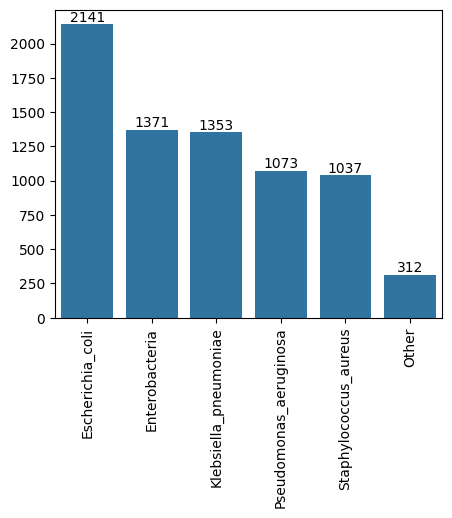

In [149]:
import seaborn as sns 
import matplotlib.pyplot as plt

t = tbl_microorganismo_recoded['microorganismo_recoded'].value_counts()

fig,ax = plt.subplots(1,1,figsize=(5,4,))
sns.barplot(x=t.index.values, y=t.values, fill=True)
# Add labels
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.show()

In [ ]:
sns.barplot()

### collapse 'record_id' into columns 
- Pivotar info de episodios en columnas: ***cultivo_previo_microorganismo_1, ..., cultivo_previo_microorganismo_n***

### tbl_antibiograma

In [120]:
tbl_antibiograma = pd.read_sql_query("SELECT * FROM antibiograma", con=conn)
tbl_antibiograma.head()

,episode_id,antimicrobiano,cmi,interpretacion
0,1,Cefazolina,>16 mg/L,R
1,1,Trimetoprim,>4 mg/L,R
2,1,Ertapenem,>1 mg/L,R
3,1,Cefuroxima,>8 mg/L,R
4,1,Trimetroprim/sulfametoxazol,>4/76 mg/L,R


In [ ]:
antibiotic_family = {
    # Beta-lactams (Penicillins, Cephalosporins, Carbapenems, Monobactams)
    "Ampicilina": "Beta-lactam",
    "Amoxicilina": "Beta-lactam",
    "Amoxicilina/clavulánico": "Beta-lactam",
    "Ampicilina/sulbactam": "Beta-lactam",
    "Piperacilina": "Beta-lactam",
    "Piperacilina/tazobactam": "Beta-lactam",
    "Ticarcilina": "Beta-lactam",
    "Ticarcilina/clavulanico": "Beta-lactam",
    "Cefalexina": "Beta-lactam",
    "Cefuroxima": "Beta-lactam",
    "Cefotaxima": "Beta-lactam",
    "Cefotaxima/clavulanico": "Beta-lactam",
    "Cefixime": "Beta-lactam",
    "Ceftazidima": "Beta-lactam",
    "Ceftazidima/avibactam": "Beta-lactam",
    "Ceftazidima/clavulanico": "Beta-lactam",
    "Ceftolozano/tazobactam": "Beta-lactam",
    "Cefepime": "Beta-lactam",
    "Ceftarolina": "Beta-lactam",
    "Cefoxitina": "Beta-lactam",
    "Cefazolina": "Beta-lactam",
    "Cefalotina": "Beta-lactam",
    "Cefiderocol": "Beta-lactam",
    "Meropenem": "Beta-lactam",
    "Meropenem (E-test)": "Beta-lactam",
    "Imipenem": "Beta-lactam",
    "Ertapenem": "Beta-lactam",
    "Aztreonam": "Beta-lactam",

    # Aminoglycosides
    "Gentamicina": "Aminoglycoside",
    "Tobramicina": "Aminoglycoside",
    "Amikacina": "Aminoglycoside",
    "Netilmicina": "Aminoglycoside",
    "Kanamicina": "Aminoglycoside",

    # Fluoroquinolones / quinolones
    "Ciprofloxacino": "Fluoroquinolone",
    "Levofloxacino": "Fluoroquinolone",
    "Moxifloxacino": "Fluoroquinolone",
    "Norfloxacino": "Fluoroquinolone",
    "Ofloxacino": "Fluoroquinolone",
    "Ácido nalidíxico": "Fluoroquinolone",

    # Gram+ specific (glycopeptides, oxazolidinone, lipopeptide)
    "Vancomicina": "Gram+ agents",
    "Teicoplanina": "Gram+ agents",
    "Linezolid": "Gram+ agents",
    "Daptomicina": "Gram+ agents",

    # Tetracyclines
    "Tetraciclina": "Tetracycline",
    "Doxiciclina": "Tetracycline",
    "Minociclina": "Tetracycline",
}


Index(['Levofloxacino', 'Tobramicina', 'Ciprofloxacino', 'Amikacina',
       'Trimetroprim/sulfametoxazol', 'Gentamicina', 'Ceftazidima', 'Cefepime',
       'Piperacilina/tazobactam', 'Ticarcilina', 'Imipenem', 'Colistina',
       'Cefotaxima', 'Fosfomicina', 'Cefuroxima', 'Ertapenem', 'Ampicilina',
       'Meropenem', 'Piperacilina', 'Amoxicilina/clavulánico', 'Aztreonam',
       'Tigeciclina', 'Cefixime', 'Ceftazidima/avibactam',
       'Ceftolozano/tazobactam', 'Cloranfenicol', 'Norfloxacino',
       'Ampicilina/sulbactam', 'Nitrofurantoina', 'Cefalexina', 'Tetraciclina',
       'Cefoxitina', 'Cefazolina', 'Minociclina', 'Eritromicina', 'Oxacilina',
       'Vancomicina', 'Daptomicina', 'Linezolid', 'Teicoplanina', 'Penicilina',
       'Ceftarolina', 'Rifampicina', 'Ácido fusídico', 'Kanamicina',
       'Synercid', 'Clindamicina', 'Moxifloxacino', 'Azitromicina',
       'Mupirocina', 'Pristanamicina', 'Ofloxacino', 'Trimetoprim',
       'Mecillinam', 'Ticarcilina/clavulanico', 'Netil

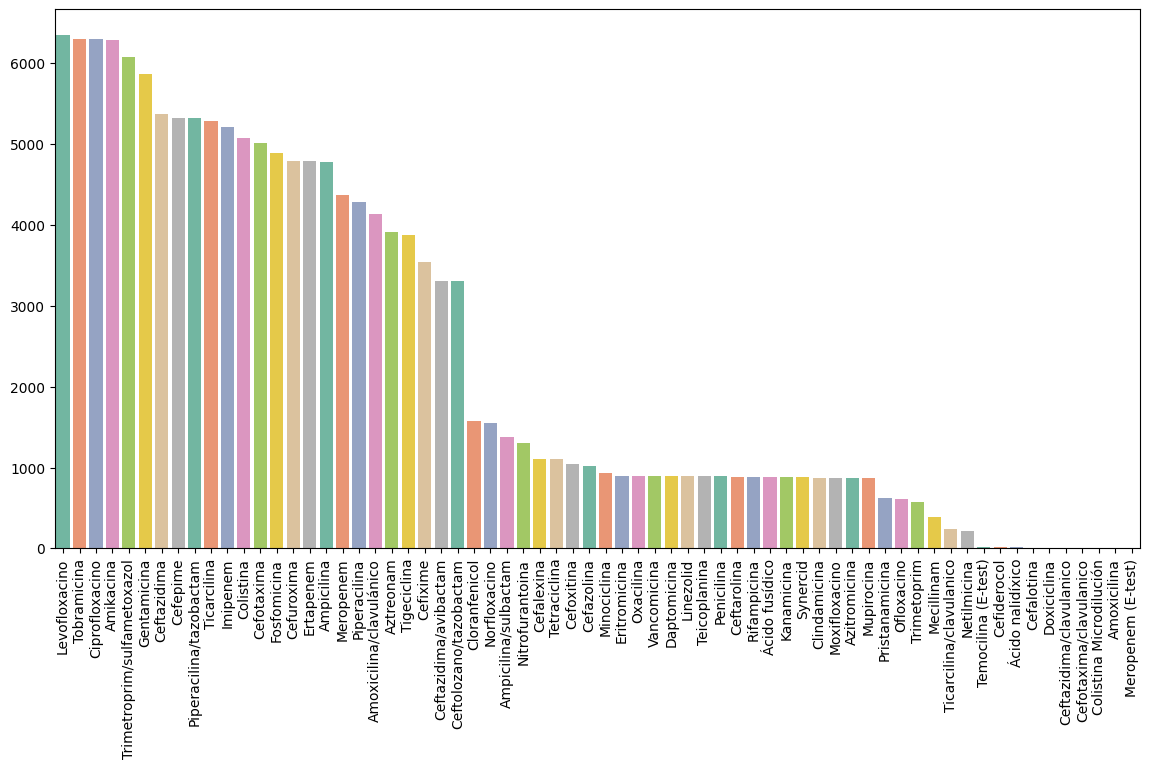

In [158]:
a = tbl_antibiograma['antimicrobiano'].value_counts()

fig,ax=plt.subplots(1,1,figsize=(14,7))
sns.barplot(x=a.index.values, y=a.values, palette='Set2')
plt.xticks(rotation=90)
plt.show()

In [124]:
tbl_antibiograma[tbl_antibiograma['episode_id']==34]

,episode_id,antimicrobiano,cmi,interpretacion
354,34,Ampicilina,>8 mg/L,R
355,34,Trimetroprim/sulfametoxazol,>4/76 mg/L,R
356,34,Amoxicilina/clavulánico,32 mg/L,R
357,34,Ticarcilina,>16 mg/L,R
358,34,Piperacilina,>16 mg/L,R
359,34,Ampicilina/sulbactam,>16/8 mg/L,R
38604,34,Cefuroxima,<=8 mg/L,I
50173,34,Cefalexina,<=16 mg/L,S
50174,34,Imipenem,<=1 mg/L,S
50175,34,Ciprofloxacino,0.25 mg/L,S
